# 10. Python — Elbow Method

Let's implement it.

In [100]:
from sklearn.cluster import KMeans
import pandas as pd

df = pd.read_csv("Mall_Customers.csv")

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

inertias = []

for k in range(2, 11):
    model = KMeans(
        n_clusters = k,
        random_state = 42,
        n_init = 10
    )

    model.fit(X)

    inertias.append(model.inertia_)

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


# 11. Plot the Elbow Curve

Now:

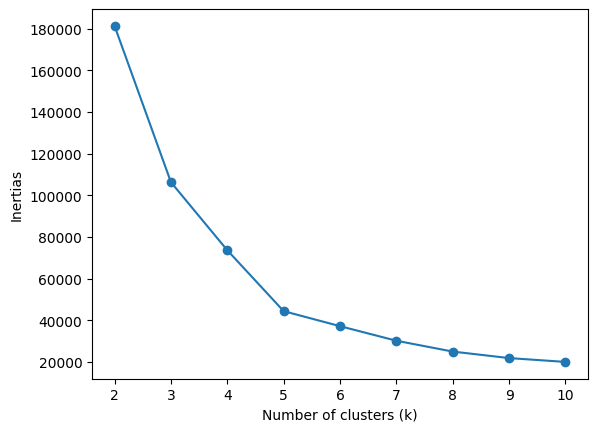

In [101]:
import matplotlib.pyplot as plt

k_values = range(2, 11)

plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertias")
plt.show()

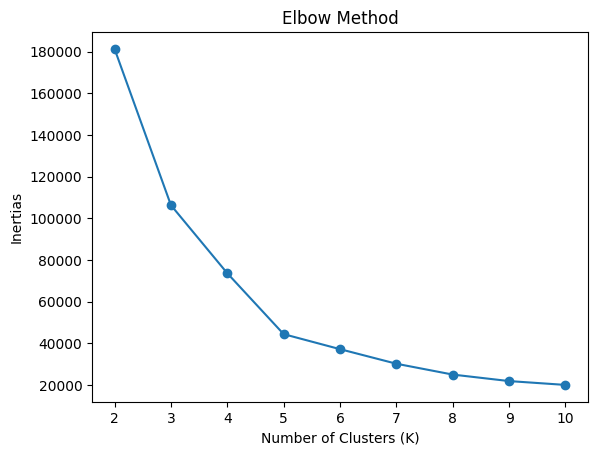

In [102]:
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Mall_Customers.csv")

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

inertias = []

for k in range(2, 11):
    model = KMeans(
        n_clusters = k,
        random_state = 42,
        n_init = 10
    )

    model.fit(X)

    inertias.append(model.inertia_)

X.head()

k_values = range(2, 11)

plt.plot(k_values, inertias, marker = "o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertias")
plt.title("Elbow Method")
plt.show()

# 19. Python — Silhouette Score

Scikit-learn provides:

In [103]:
from sklearn.metrics import silhouette_score

model = KMeans(
    n_clusters = 5,
    random_state = 42,
    n_init = 10
)

labels = model.fit_predict(X)

score = silhouette_score(X, labels)

print(score)

0.553931997444648


# 20. Calculate Silhouette Scores for Different K

We can test several K values.

In [104]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    model = KMeans(
        n_clusters = k,
        random_state = 42,
        n_init = 10
    )

    labels = model.fit_predict(X)

    score = silhouette_score(X, labels)

    silhouette_scores.append(score)

silhouette_scores

[0.2968969162503008,
 0.46761358158775435,
 0.4931963109249047,
 0.553931997444648,
 0.53976103063432,
 0.5288104473798049,
 0.45481197931195283,
 0.4561091950997367,
 0.4410568674364981]

# 21. Plot Silhouette Scores

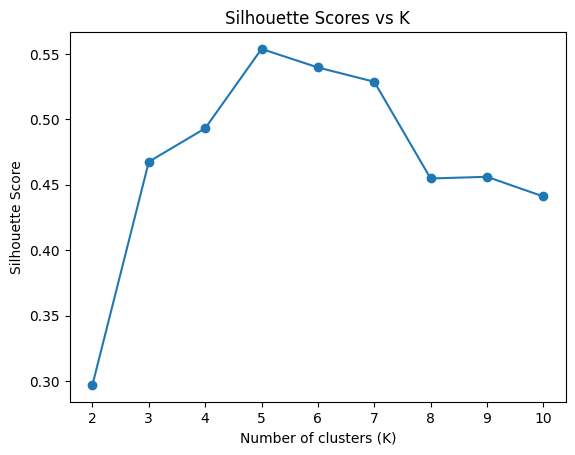

In [105]:
plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores vs K")
plt.show()

# 28. Complete Example

Let's create a simple dataset.

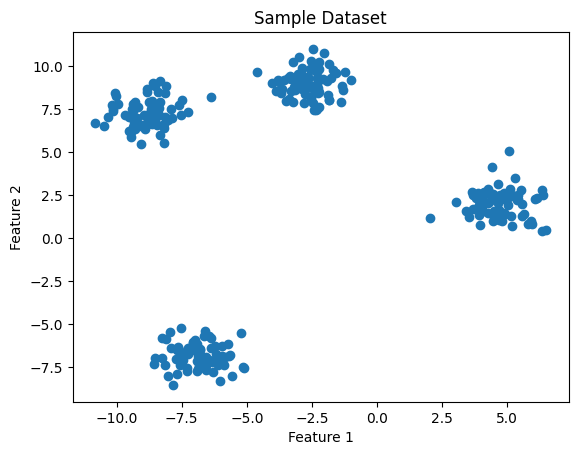

In [106]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, y = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.8,
    random_state=42
)

plt.scatter(X[:, 0], X[:, 1])
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Sample Dataset")
plt.show()

The dataset contains four underlying groups.

But imagine that we don't know that.

We will try to discover K.

# 29. Step 1 — Calculate Inertia

### Practic 10.

# 30. Step 2 — Plot Elbow

### See 11.

# 31. Step 3 — Calculate Silhouette

### See 19 and 20.

# 32. Step 4 — Plot Silhouette

### See 21.

# 33. Step 5 — Train Final Model

### See 19 and 20.

# 46. One Complete Notebook

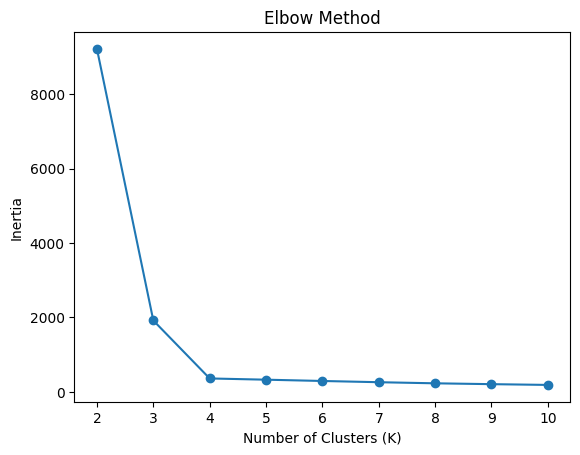

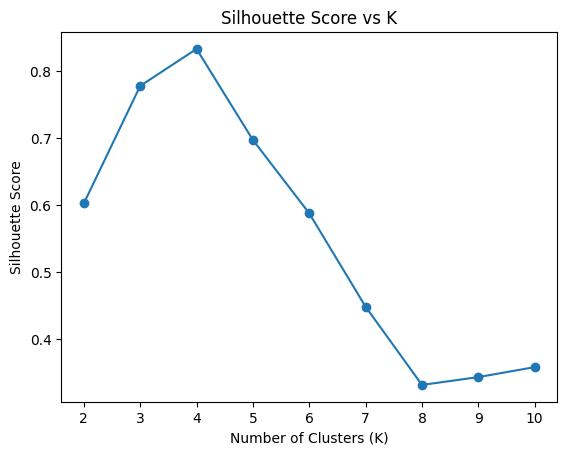

Best K according to silhouette score: 4


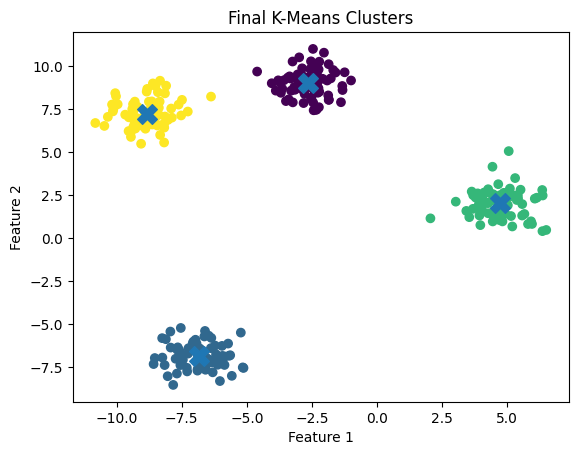

In [108]:
# K-MEANS: CHOOSING THE NUMBER OF CLUSTERS

import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score


# 1. Create dataset

X, y = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.8,
    random_state=42
)


# 2. Elbow Method

K_values = range(2, 11)

inertias = []

for k in K_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X)

    inertias.append(model.inertia_)


# 3. Plot Elbow Curve

plt.plot(
    K_values,
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()


# 4. Silhouette Score

silhouette_scores = []

for k in K_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X)

    score = silhouette_score(X, labels)

    silhouette_scores.append(score)


# 5. Plot Silhouette Scores

plt.plot(
    K_values,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")

plt.show()


# 6. Choose K

best_k = K_values[
    silhouette_scores.index(max(silhouette_scores))
]

print("Best K according to silhouette score:", best_k)


# 7. Train Final Model

final_model = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

labels = final_model.fit_predict(X)


# 8. Get Centroids

centers = final_model.cluster_centers_


# 9. Visualize Final Clusters

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels
)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=200
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Final K-Means Clusters")

plt.show()